##### Universidad Autónoma de Guadalajara
Aprendizaje Automatizado para la Gestión de Datos Masivos   

Profesor: Paulo López Meyer. 

Estudiante: Anayansi Cristina Hernández Abrego. 

Código vistos en clase ( tarea 08). 

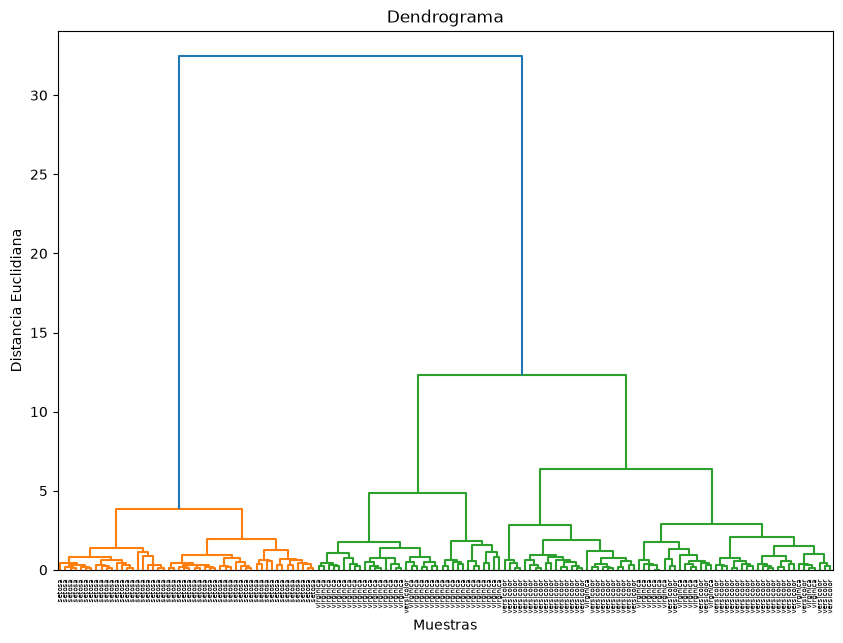

In [3]:
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Cargar conjunto de datos de ejemplo
data = load_iris()
X = data.data

# Aplicar clustering jerárquico
linked = sch.linkage(X, method='ward')

# Dibujar el dendrograma
plt.figure(figsize=(10, 7))
sch.dendrogram(linked, labels=data.target_names[data.target])
plt.title('Dendrograma')
plt.xlabel('Muestras')
plt.ylabel('Distancia Euclidiana')
plt.show()



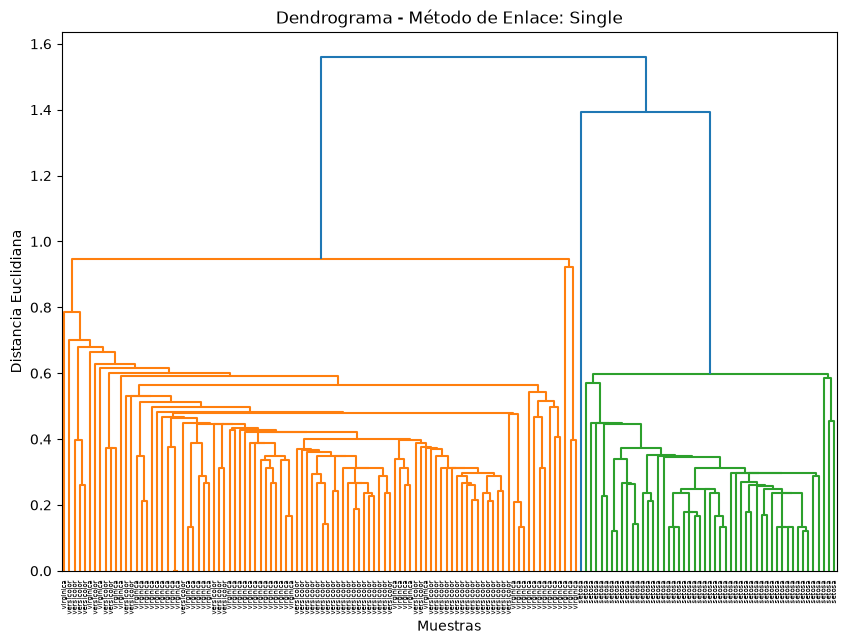

Método de Enlace: Single - Puntuación de la Silueta: 0.505


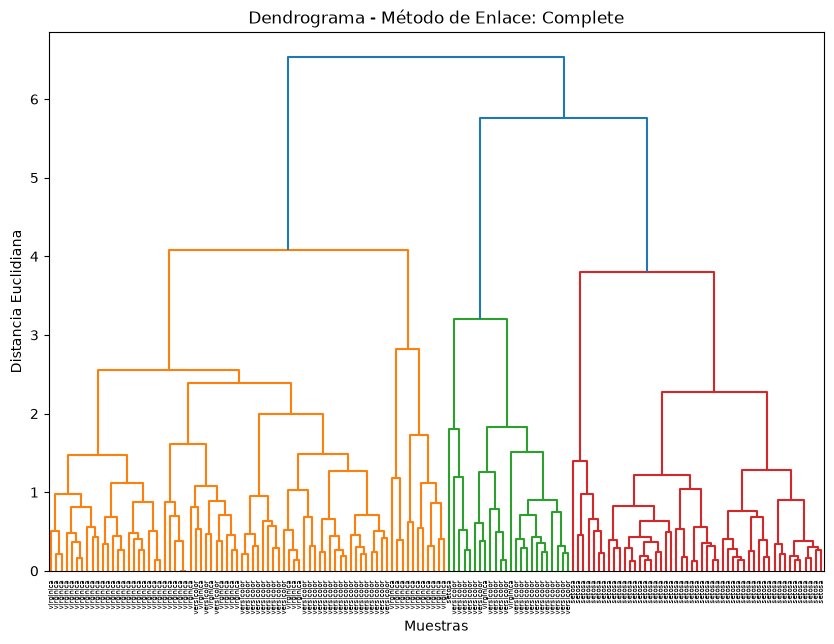

Método de Enlace: Complete - Puntuación de la Silueta: 0.450


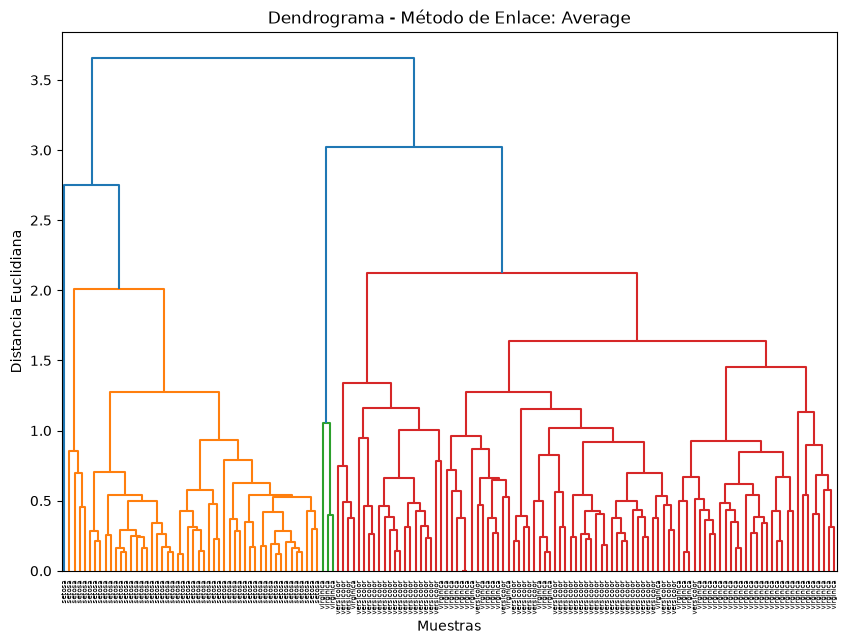

Método de Enlace: Average - Puntuación de la Silueta: 0.480


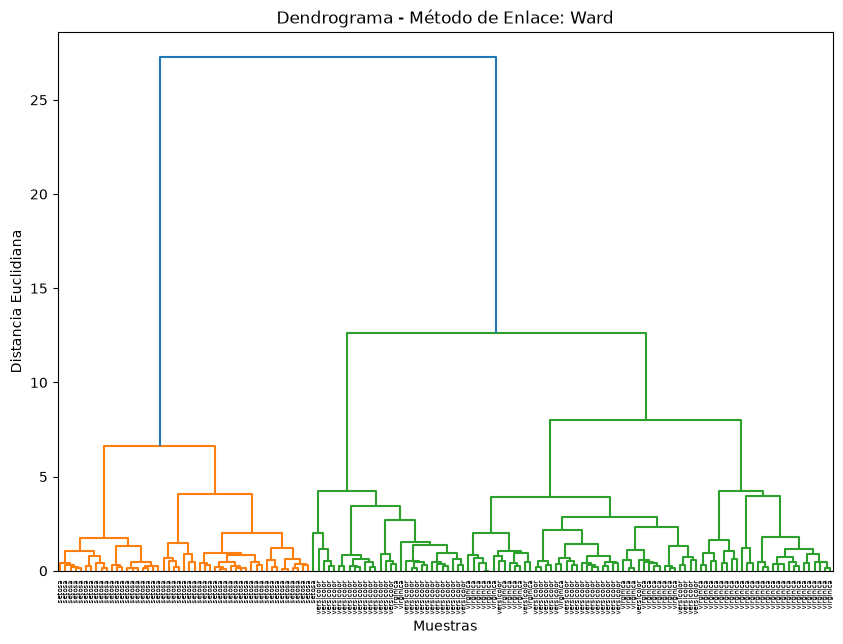

Método de Enlace: Ward - Puntuación de la Silueta: 0.447


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar clustering jerárquico con diferentes métodos de enlace
methods = ['single', 'complete', 'average', 'ward']
for method in methods:
    linked = sch.linkage(X_scaled, method=method)
    plt.figure(figsize=(10, 7))
    sch.dendrogram(linked, labels=data.target_names[data.target])
    plt.title(f'Dendrograma - Método de Enlace: {method.capitalize()}')
    plt.xlabel('Muestras')
    plt.ylabel('Distancia Euclidiana')
    plt.show()

    # Obtener clusters usando el método de enlace
    clusters = sch.fcluster(linked, t=3, criterion='maxclust')
    score = silhouette_score(X_scaled, clusters)
    print(f'Método de Enlace: {method.capitalize()} - Puntuación de la Silueta: {score:.3f}')
